In [4]:
import numpy as np
import matplotlib.pyplot as plt
import stingray
from stingray import Lightcurve, AveragedCrossspectrum, AveragedPowerspectrum, DynamicalPowerspectrum

# Simple simulated signals produce non-linear phase lags

This notebook produces simulated light-curves to test phase lags behaviour as in Ricketts and Marcel 2026. Simulations are in paper order, divided by paper section. Short explanations accompany each simulation.

In [5]:
def make_decaying_sine(constant, factor, nu, Dnu, phi, t, kick=False, kick_period = 0.2, phase=0):
    """Decaying sine-wave"""
    alpha = np.pi * Dnu
    if kick == False:
        return constant + factor*constant*np.exp(-alpha * np.abs(t)) * np.sin(2*np.pi*nu*t - 2*np.pi*phi + phase)
    else:
        total_kicks = np.max(t) // kick_period + 1
        time_scatter_per_kick = np.random.normal(1, 0.1, int(total_kicks)) * kick_period
        print(time_scatter_per_kick, total_kicks)
        time = []
        i = 0
        j = 0
        t_i = t[i]
        kick_j = time_scatter_per_kick[j]
        while t_i < np.max(t):
            time_block = constant + factor*constant*np.exp(-alpha * np.abs(t_i%kick_j)) * np.sin(2*np.pi*nu*(t_i%kick_j) - 2*np.pi*phi)
            print(time_block)
            time.append(time_block)
            i += 1
            if t[i] >= sum(time_scatter_per_kick[:j]):
                j += 1
            t_i = t[i]
            if j >= len(time_scatter_per_kick):
                break
            else:
                kick_j = time_scatter_per_kick[j]
        return np.array(time)

64it [00:00, 11920.40it/s]
64it [00:00, 12721.46it/s]
64it [00:00, 12541.37it/s]


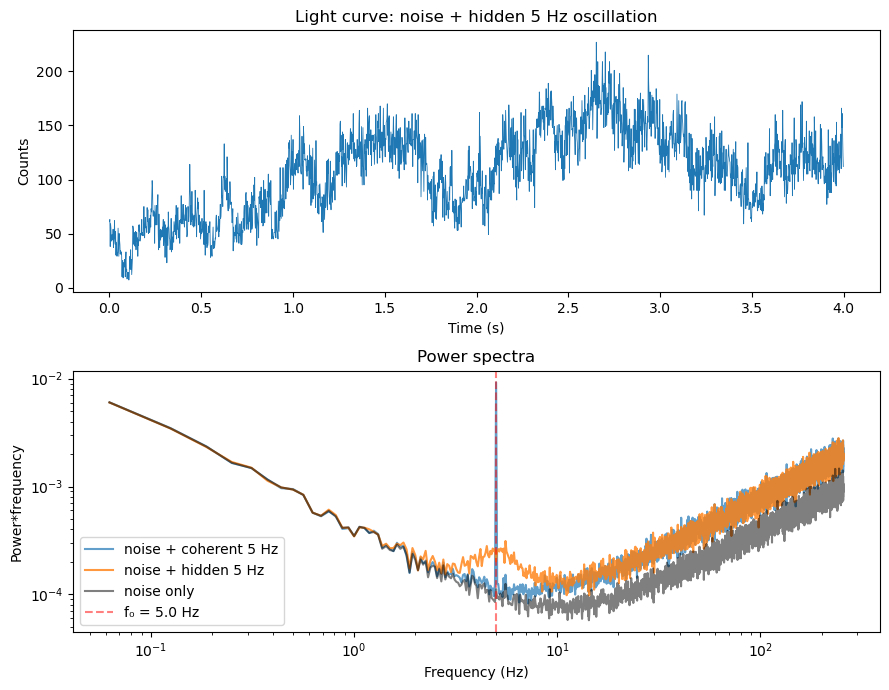

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from stingray import simulator, Lightcurve, Powerspectrum

# --- Broadband noise setup (your original) ---
dt = 1/512
mean = 1000
T = 1024/dt
rms = 0.5
sim = simulator.Simulator(N=int(T), mean=mean, dt=dt, rms=rms, poisson=True)
lc1 = sim.simulate(2)   # power-law index 2 (red noise)

# --- Hidden oscillation: fixed-frequency carrier with diffusing phase ---
f0      = 5.0     # Hz, "carrier" frequency we want to hide
A       = 15.0    # oscillation amplitude (in counts, ~15% of mean)
D_phase = 8.0     # phase-diffusion coefficient [rad^2 / s]
                  # larger = phase wanders faster = peak smears more

t = np.arange(lc1.n) * dt

# Random-walk phase: dphi/dt = 2*pi*f0 + sqrt(2*D) * white noise
rng = np.random.default_rng(42)
dphi = 2*np.pi*f0*dt + np.sqrt(2*D_phase*dt) * rng.standard_normal(lc1.n)
phase = np.cumsum(dphi)

hidden = A * np.cos(phase)

# --- Combine and Poisson-sample ---
combined_rate = lc1.counts + hidden
combined_rate = np.clip(combined_rate, 0, None)        # rates must be >= 0
combined_counts = rng.poisson(combined_rate)

lc_hidden = Lightcurve(t, combined_counts, dt=dt, skip_checks=True)

# --- Power spectra to verify "invisibility" ---
ps_noise  = AveragedPowerspectrum(lc1,        norm='frac', segment_size=16)
ps_hidden = AveragedPowerspectrum(lc_hidden,  norm='frac', segment_size=16)

# For comparison: a coherent (NOT hidden) oscillation at the same freq
coherent = A * np.cos(2*np.pi*f0*t)
lc_coh   = Lightcurve(t, rng.poisson(np.clip(lc1.counts + coherent, 0, None)),
                      dt=dt, skip_checks=True)
ps_coh   = AveragedPowerspectrum(lc_coh, norm='frac', segment_size=16)

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(9, 7))

axes[0].plot(t[:2048], combined_counts[:2048], lw=0.6)
axes[0].set(xlabel='Time (s)', ylabel='Counts',
            title='Light curve: noise + hidden 5 Hz oscillation')

axes[1].loglog(ps_coh.freq,    ps_coh.freq*ps_coh.power,    label='noise + coherent 5 Hz', alpha=0.7)
axes[1].loglog(ps_hidden.freq, ps_hidden.freq*ps_hidden.power, label='noise + hidden 5 Hz',   alpha=0.8)
axes[1].loglog(ps_noise.freq,  ps_noise.freq*ps_noise.power,  label='noise only', alpha=0.5, color='k')
axes[1].axvline(f0, ls='--', color='red', alpha=0.5, label=f'f₀ = {f0} Hz')
axes[1].set(xlabel='Frequency (Hz)', ylabel='Power*frequency', title='Power spectra')
axes[1].legend()

plt.tight_layout()
plt.show()

64it [00:00, 12410.33it/s]
64it [00:00, 12635.82it/s]
64it [00:00, 10474.71it/s]
64it [00:00, 5638.33it/s]
64it [00:00, 6496.19it/s]


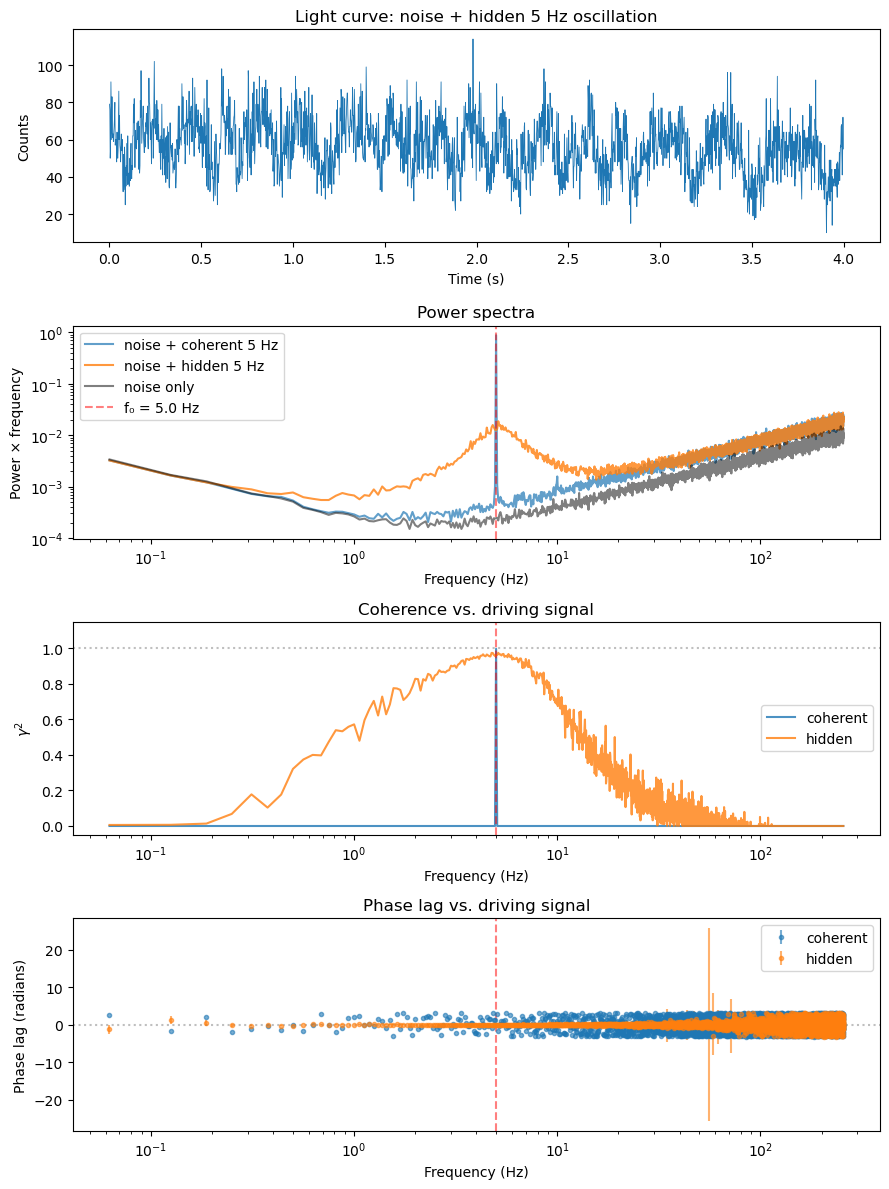

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from stingray import simulator, Lightcurve, Powerspectrum, AveragedCrossspectrum, AveragedPowerspectrum

# --- Broadband noise setup ---
dt = 1/512
mean = 100
T = 1024/dt
rms = 0.5
sim = simulator.Simulator(N=int(T), mean=mean, dt=dt, rms=rms, poisson=True)
lc1 = sim.simulate(2)

# --- Hidden oscillation: diffusing-phase carrier ---
f0      = 5.0
A       = 15.0
D_phase = 8.0

t = np.arange(lc1.n) * dt
rng = np.random.default_rng(42)
dphi  = 2*np.pi*f0*dt + np.sqrt(2*D_phase*dt) * rng.standard_normal(lc1.n)
phase = np.cumsum(dphi)
hidden = A * np.cos(phase)

# --- Combine and Poisson-sample ---
combined_rate   = np.clip(lc1.counts + hidden, 0, None)
combined_counts = rng.poisson(combined_rate)
lc_hidden = Lightcurve(t, combined_counts, dt=dt, skip_checks=True)

# Coherent comparison
coherent = A * np.cos(2*np.pi*f0*t)
lc_coh   = Lightcurve(t, rng.poisson(np.clip(lc1.counts + coherent, 0, None)),
                      dt=dt, skip_checks=True)

# Driving signals as "reference" light curves (no noise, no Poisson)
# Shift to a positive mean so Lightcurve is happy; the cross-spectrum
# at f > 0 is unaffected by the DC offset.
lc_drive_hidden = Lightcurve(t, hidden   + 2*A, dt=dt, skip_checks=True)
lc_drive_coh    = Lightcurve(t, coherent + 2*A, dt=dt, skip_checks=True)

# --- Averaged spectra (segments needed for coherence) ---
seg = 16.0   # seconds per segment → df = 1/seg = 0.0625 Hz

ps_noise   = AveragedPowerspectrum(lc1,        segment_size=seg, norm='frac')
ps_hidden  = AveragedPowerspectrum(lc_hidden,  segment_size=seg, norm='frac')
ps_coh     = AveragedPowerspectrum(lc_coh,     segment_size=seg, norm='frac')

cs_hidden  = AveragedCrossspectrum(lc_hidden, lc_drive_hidden, segment_size=seg, norm='frac')
cs_coh     = AveragedCrossspectrum(lc_coh,    lc_drive_coh,    segment_size=seg, norm='frac')

coh_h, _ = cs_hidden.coherence()
coh_c, _ = cs_coh.coherence()
lag_h, lag_h_err = cs_hidden.phase_lag()
lag_c, lag_c_err = cs_coh.phase_lag()

# --- Plot ---
fig, axes = plt.subplots(4, 1, figsize=(9, 12))

axes[0].plot(t[:2048], combined_counts[:2048], lw=0.6)
axes[0].set(xlabel='Time (s)', ylabel='Counts',
            title='Light curve: noise + hidden 5 Hz oscillation')

axes[1].loglog(ps_coh.freq,    ps_coh.freq*ps_coh.power,
               label='noise + coherent 5 Hz', alpha=0.7)
axes[1].loglog(ps_hidden.freq, ps_hidden.freq*ps_hidden.power,
               label='noise + hidden 5 Hz',   alpha=0.8)
axes[1].loglog(ps_noise.freq,  ps_noise.freq*ps_noise.power,
               label='noise only', alpha=0.5, color='k')
axes[1].axvline(f0, ls='--', color='red', alpha=0.5, label=f'f₀ = {f0} Hz')
axes[1].set(xlabel='Frequency (Hz)', ylabel='Power × frequency',
            title='Power spectra')
axes[1].legend()

axes[2].semilogx(cs_coh.freq,    coh_c, label='coherent', alpha=0.8)
axes[2].semilogx(cs_hidden.freq, coh_h, label='hidden',   alpha=0.8)
axes[2].axvline(f0, ls='--', color='red', alpha=0.5)
axes[2].axhline(1.0, ls=':', color='gray', alpha=0.5)
axes[2].set(xlabel='Frequency (Hz)', ylabel=r'$\gamma^2$',
            title='Coherence vs. driving signal', ylim=(-0.05, 1.15))
axes[2].legend()

axes[3].errorbar(cs_coh.freq,    lag_c, yerr=lag_c_err,
                 fmt='.', alpha=0.6, label='coherent')
axes[3].errorbar(cs_hidden.freq, lag_h, yerr=lag_h_err,
                 fmt='.', alpha=0.6, label='hidden')
axes[3].axvline(f0, ls='--', color='red', alpha=0.5)
axes[3].axhline(0.0, ls=':', color='gray', alpha=0.5)
axes[3].set(xscale='log', xlabel='Frequency (Hz)', ylabel='Phase lag (radians)',
            title='Phase lag vs. driving signal')
axes[3].legend()

plt.tight_layout()
plt.show()

64it [00:00, 12446.58it/s]
64it [00:00, 12672.81it/s]
64it [00:00, 15144.45it/s]
64it [00:00, 5497.46it/s]
64it [00:00, 6875.03it/s]


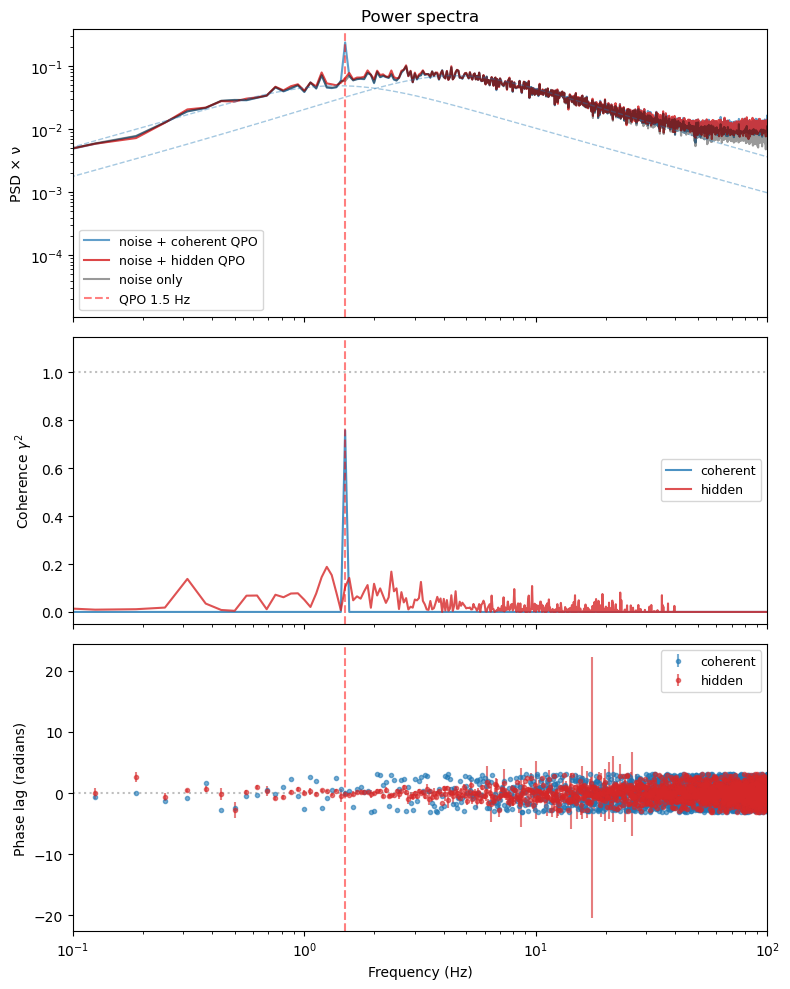

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from stingray import simulator, Lightcurve, Powerspectrum, AveragedCrossspectrum, AveragedPowerspectrum

# --- Time-domain setup ---
dt   = 1/512
mean = 100
T    = 1024 / dt           # number of bins
rms  = 0.5

sim = simulator.Simulator(N=int(T), mean=mean, dt=dt, rms=rms, poisson=True)
w   = np.fft.rfftfreq(sim.N, d=sim.dt)[1:]   # positive freqs only

# --- Two-Lorentzian broadband PSD model (matches blue curve shape) ---
def lorentzian(f, f0, q, norm):
    """Zero-centered Lorentzian with peak at f0, quality q, normalisation norm."""
    df = f0 / q
    return norm * (df / np.pi) / ((f - f0)**2 + df**2)

#                  f0   q     norm
L1 = lorentzian(w, 0.4, 0.3,  1.0)   # low-frequency hump
L2 = lorentzian(w, 2.0, 0.5,  1.2)   # high-frequency hump
psd_model = L1 + L2

lc1 = sim.simulate(psd_model)        # noise light curve with this PSD

# --- Hidden QPO: diffusing-phase oscillator at 1.5 Hz ---
f0_qpo  = 1.5
A       = 12.0
D_phase = 4.0                        # phase-diffusion coefficient

t   = np.arange(lc1.n) * dt
rng = np.random.default_rng(7)

dphi  = 2*np.pi*f0_qpo*dt + np.sqrt(2*D_phase*dt) * rng.standard_normal(lc1.n)
phase = np.cumsum(dphi)
hidden = A * np.cos(phase)

# Coherent comparison QPO
coherent = A * np.cos(2*np.pi*f0_qpo*t)

# --- Combine + Poisson sample ---
combined_rate_h = np.clip(lc1.counts + hidden,   0, None)
combined_rate_c = np.clip(lc1.counts + coherent, 0, None)

lc_hidden = Lightcurve(t, rng.poisson(combined_rate_h), dt=dt, skip_checks=True)
lc_coh    = Lightcurve(t, rng.poisson(combined_rate_c), dt=dt, skip_checks=True)

# Reference (pure driver) lightcurves, shifted positive
lc_drive_h = Lightcurve(t, hidden   + 2*A, dt=dt, skip_checks=True)
lc_drive_c = Lightcurve(t, coherent + 2*A, dt=dt, skip_checks=True)

# --- Averaged spectra ---
seg = 16.0
ps_noise  = AveragedPowerspectrum(lc1,       segment_size=seg, norm='frac')
ps_hidden = AveragedPowerspectrum(lc_hidden, segment_size=seg, norm='frac')
ps_coh    = AveragedPowerspectrum(lc_coh,    segment_size=seg, norm='frac')

cs_h = AveragedCrossspectrum(lc_hidden, lc_drive_h, segment_size=seg, norm='frac')
cs_c = AveragedCrossspectrum(lc_coh,    lc_drive_c, segment_size=seg, norm='frac')

coh_h, _      = cs_h.coherence()
coh_c, _      = cs_c.coherence()
lag_h, lag_he = cs_h.phase_lag()
lag_c, lag_ce = cs_c.phase_lag()

# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

axes[0].loglog(ps_coh.freq,    ps_coh.freq*ps_coh.power,
               color='C0', label='noise + coherent QPO', alpha=0.7)
axes[0].loglog(ps_hidden.freq, ps_hidden.freq*ps_hidden.power,
               color='C3', label='noise + hidden QPO',   alpha=0.85)
axes[0].loglog(ps_noise.freq,  ps_noise.freq*ps_noise.power,
               color='k',  label='noise only', alpha=0.4)
# Overlay the input Lorentzian components (arbitrary scale, just for shape)
scale = (ps_noise.freq*ps_noise.power)[np.argmin(np.abs(ps_noise.freq-0.4))] / \
        (w[np.argmin(np.abs(w-0.4))] * L1[np.argmin(np.abs(w-0.4))])
axes[0].loglog(w, w*L1*scale, '--', color='C0', alpha=0.4, lw=1)
axes[0].loglog(w, w*L2*scale, '--', color='C0', alpha=0.4, lw=1)
axes[0].axvline(f0_qpo, ls='--', color='red', alpha=0.5, label=f'QPO {f0_qpo} Hz')
axes[0].set(ylabel='PSD × ν', title='Power spectra')
axes[0].legend(fontsize=9)

axes[1].semilogx(cs_c.freq, coh_c, color='C0', label='coherent', alpha=0.8)
axes[1].semilogx(cs_h.freq, coh_h, color='C3', label='hidden',   alpha=0.8)
axes[1].axvline(f0_qpo, ls='--', color='red', alpha=0.5)
axes[1].axhline(1.0, ls=':', color='gray', alpha=0.5)
axes[1].set(ylabel=r'Coherence $\gamma^2$', ylim=(-0.05, 1.15))
axes[1].legend(fontsize=9)

axes[2].errorbar(cs_c.freq, lag_c, yerr=lag_ce, fmt='.',
                 color='C0', alpha=0.6, label='coherent')
axes[2].errorbar(cs_h.freq, lag_h, yerr=lag_he, fmt='.',
                 color='C3', alpha=0.6, label='hidden')
axes[2].axvline(f0_qpo, ls='--', color='red', alpha=0.5)
axes[2].axhline(0.0, ls=':', color='gray', alpha=0.5)
axes[2].set(xscale='log', xlabel='Frequency (Hz)', ylabel='Phase lag (radians)')
axes[2].legend(fontsize=9)
axes[2].set_xlim(0.1,100)

plt.tight_layout()
plt.show()


noise variance:     2508.11
response variance:  99.46  (4.0% of noise)


64it [00:00, 11768.32it/s]
64it [00:00, 12886.96it/s]
64it [00:00, 7348.96it/s]


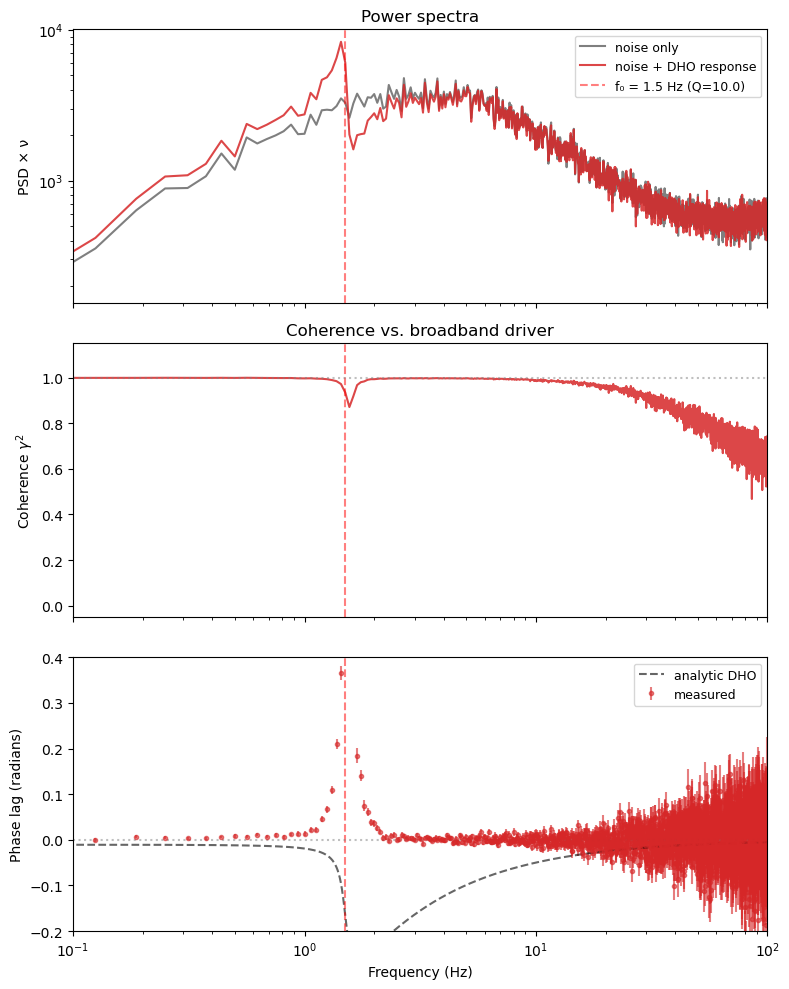

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from stingray import (simulator, Lightcurve, Powerspectrum,
                      AveragedCrossspectrum, AveragedPowerspectrum)

# --- Time-domain setup ---
dt   = 1/512
mean = 100
T    = 1024 / dt
rms  = 0.5

sim = simulator.Simulator(N=int(T), mean=mean, dt=dt, rms=rms, poisson=True)
w   = np.fft.rfftfreq(sim.N, d=sim.dt)[1:]

# --- Two-Lorentzian broadband noise PSD (blue-curve shape) ---
def lorentzian(f, f0, q, norm):
    df = f0 / q
    return norm * (df / np.pi) / ((f - f0)**2 + df**2)

psd_model = lorentzian(w, 0.4, 0.3, 1.0) + lorentzian(w, 2.0, 0.5, 1.2)
lc1 = sim.simulate(psd_model)

# --- DHO transfer function applied to lc1 ---
def dho_filter(x, dt, f0, zeta, gain=1.0):
    """Pass x(t) through a damped harmonic oscillator H(f)."""
    N = len(x)
    freq = np.fft.rfftfreq(N, d=dt)
    w_   = 2*np.pi*freq
    w0   = 2*np.pi*f0
    H    = w0**2 / (w0**2 - w_**2 + 2j*zeta*w0*w_)
    X    = np.fft.rfft(x - x.mean())
    y    = np.fft.irfft(gain * H * X, n=N)
    return y

f0_qpo = 1.5
zeta   = 0.05                    # Q = 1/(2 zeta) = 10
gain   = 0.10                    # small response amplitude

# Driver = mean-subtracted noise; response = its DHO-filtered version
driver   = lc1.counts - lc1.counts.mean()
response = dho_filter(driver, dt, f0=f0_qpo, zeta=zeta, gain=gain)

print(f'noise variance:     {driver.var():.2f}')
print(f'response variance:  {response.var():.2f}  '
      f'({100*response.var()/driver.var():.1f}% of noise)')

# --- Combine + Poisson sample ---
t   = np.arange(lc1.n) * dt
rng = np.random.default_rng(11)

combined_rate = np.clip(lc1.counts + response, 0, None)
lc_hidden     = Lightcurve(t, rng.poisson(combined_rate), dt=dt, skip_checks=True)
lc_noise_only = Lightcurve(t, rng.poisson(lc1.counts),    dt=dt, skip_checks=True)

# Reference = the original (pre-filter) noise driver, shifted positive
lc_drive = Lightcurve(t, driver + 5*driver.std(), dt=dt, skip_checks=True)

# --- Averaged spectra ---
seg = 16.0
ps_noise  = AveragedPowerspectrum(lc_noise_only, segment_size=seg, norm='leahy')
ps_hidden = AveragedPowerspectrum(lc_hidden,     segment_size=seg, norm='leahy')

cs = AveragedCrossspectrum(lc_hidden, lc_drive, segment_size=seg, norm='leahy')
coh, _      = cs.coherence()
lag, lag_e  = cs.phase_lag()

# --- Analytic DHO response for overlay ---
w0 = 2*np.pi*f0_qpo
H_th = w0**2 / (w0**2 - (2*np.pi*w)**2 + 2j*zeta*w0*(2*np.pi*w))
lag_th = np.angle(H_th) / (2*np.pi*w)

# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

axes[0].loglog(ps_noise.freq,  ps_noise.freq*ps_noise.power,
               color='k', alpha=0.5, label='noise only')
axes[0].loglog(ps_hidden.freq, ps_hidden.freq*ps_hidden.power,
               color='C3', alpha=0.85, label='noise + DHO response')
axes[0].axvline(f0_qpo, ls='--', color='red', alpha=0.5,
                label=f'f₀ = {f0_qpo} Hz (Q={1/(2*zeta):.1f})')
axes[0].set(ylabel='PSD × ν', title='Power spectra')
axes[0].legend(fontsize=9)

axes[1].semilogx(cs.freq, coh, color='C3', alpha=0.85)
axes[1].axvline(f0_qpo, ls='--', color='red', alpha=0.5)
axes[1].axhline(1.0, ls=':', color='gray', alpha=0.5)
axes[1].set(ylabel=r'Coherence $\gamma^2$', ylim=(-0.05, 1.15),
            title='Coherence vs. broadband driver')

axes[2].errorbar(cs.freq, lag, yerr=lag_e, fmt='.',
                 color='C3', alpha=0.6, label='measured')
axes[2].plot(w, lag_th, '--', color='k', alpha=0.6, label='analytic DHO')
axes[2].axvline(f0_qpo, ls='--', color='red', alpha=0.5)
axes[2].axhline(0.0, ls=':', color='gray', alpha=0.5)
axes[2].set(xscale='log', xlabel='Frequency (Hz)', ylabel='Phase lag (radians)',
            ylim=(-0.2, 0.4))
axes[2].legend(fontsize=9)
axes[2].set_xlim(0.1,100)

plt.tight_layout()
plt.show()

/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/simulator/simulator.py:390: UserWarning: Some bins of the light curve have counts < 0. Setting to 0
  warnings.warn("Some bins of the light curve have counts < 0. Setting to 0")
64it [00:00, 10510.81it/s]
64it [00:00, 11063.12it/s]
64it [00:00, 6091.12it/s]


Q= 1  ζ=0.500  gain=0.212  var(resp)/var(noise)=2.00%


64it [00:00, 12872.13it/s]
64it [00:00, 5065.30it/s]


Q= 2  ζ=0.250  gain=0.153  var(resp)/var(noise)=2.00%


64it [00:00, 11843.09it/s]
64it [00:00, 2021.66it/s]


Q= 5  ζ=0.100  gain=0.100  var(resp)/var(noise)=2.00%


64it [00:00, 12504.56it/s]
64it [00:00, 5283.95it/s]


Q=10  ζ=0.050  gain=0.072  var(resp)/var(noise)=2.00%


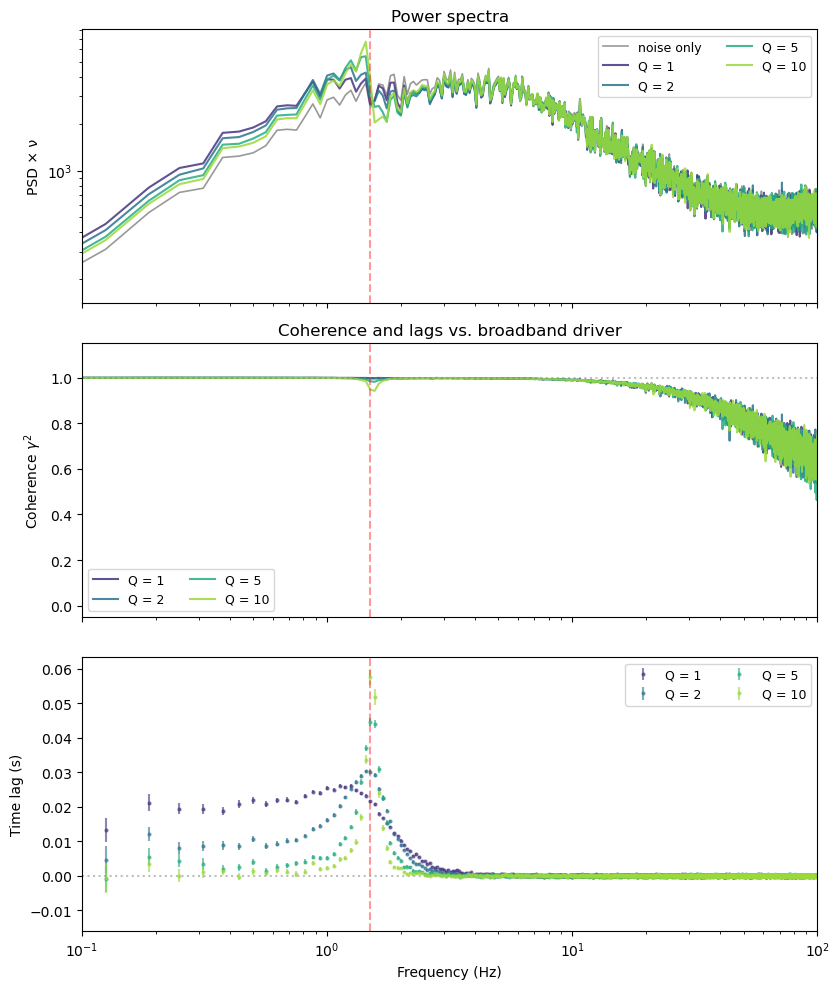

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from stingray import (simulator, Lightcurve, AveragedPowerspectrum,
                      AveragedCrossspectrum)

# --- Time-domain setup ---
dt   = 1/512
mean = 100
T    = 1024 / dt
rms  = 0.5

sim = simulator.Simulator(N=int(T), mean=mean, dt=dt, rms=rms, poisson=True)
w   = np.fft.rfftfreq(sim.N, d=sim.dt)[1:]

# --- Broadband noise ---
def lorentzian(f, f0, q, norm):
    df = f0 / q
    return norm * (df / np.pi) / ((f - f0)**2 + df**2)

psd_model = lorentzian(w, 0.4, 0.3, 1.0) + lorentzian(w, 2.0, 0.5, 1.2)
lc1 = sim.simulate(psd_model)

t      = np.arange(lc1.n) * dt
driver = lc1.counts - lc1.counts.mean()

# --- DHO filter ---
def dho_filter(x, dt, f0, zeta, gain=1.0):
    N = len(x)
    freq = np.fft.rfftfreq(N, d=dt)
    w_   = 2*np.pi*freq
    w0   = 2*np.pi*f0
    H    = w0**2 / (w0**2 - w_**2 + 2j*zeta*w0*w_)
    X    = np.fft.rfft(x - x.mean())
    return np.fft.irfft(gain * H * X, n=N)

# --- Q sweep ---
f0_qpo = 1.5
Q_vals = [1, 2, 5, 10]
zetas  = [1/(2*Q) for Q in Q_vals]

# Reference lightcurve for cross-spectrum (the broadband driver itself)
lc_drive = Lightcurve(t, driver + 5*driver.std(), dt=dt, skip_checks=True)
rng      = np.random.default_rng(11)

# Pre-compute the noise-only Poisson realisation once
lc_noise_only = Lightcurve(t, rng.poisson(lc1.counts), dt=dt, skip_checks=True)

seg = 16.0
ps_noise = AveragedPowerspectrum(lc_noise_only, segment_size=seg, norm='leahy')

results = []
target_var = 0.02 * driver.var()    # response carries ~2% of noise variance

for Q, zeta in zip(Q_vals, zetas):
    # Calibrate gain so var(response) ≈ target_var (uses unit-gain test pass)
    test = dho_filter(driver, dt, f0=f0_qpo, zeta=zeta, gain=1.0)
    gain = np.sqrt(target_var / test.var())
    response = test * gain

    rate = np.clip(lc1.counts + response, 0, None)
    lc_h = Lightcurve(t, rng.poisson(rate), dt=dt, skip_checks=True)

    ps   = AveragedPowerspectrum(lc_h, segment_size=seg, norm='leahy')
    cs   = AveragedCrossspectrum(lc_h, lc_drive, segment_size=seg, norm='leahy')
    coh, _     = cs.coherence()
    lag, lag_e = cs.time_lag()

    # Analytic DHO lag
    w0 = 2*np.pi*f0_qpo
    H_th = w0**2 / (w0**2 - (2*np.pi*w)**2 + 2j*zeta*w0*(2*np.pi*w))
    lag_th = np.angle(H_th) / (2*np.pi*w)

    results.append(dict(Q=Q, zeta=zeta, gain=gain, ps=ps, cs=cs,
                        coh=coh, lag=lag, lag_e=lag_e, lag_th=lag_th))
    print(f'Q={Q:>2d}  ζ={zeta:.3f}  gain={gain:.3f}  '
          f'var(resp)/var(noise)={response.var()/driver.var()*100:.2f}%')

# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(8.5, 10), sharex=True)
cmap = plt.cm.viridis(np.linspace(0.15, 0.85, len(Q_vals)))

axes[0].loglog(ps_noise.freq, ps_noise.freq*ps_noise.power,
               color='k', alpha=0.4, lw=1.2, label='noise only')
for r, c in zip(results, cmap):
    axes[0].loglog(r['ps'].freq, r['ps'].freq*r['ps'].power,
                   color=c, alpha=0.85, label=f"Q = {r['Q']}")
axes[0].axvline(f0_qpo, ls='--', color='red', alpha=0.4)
axes[0].set(ylabel='PSD × ν', title='Power spectra')
axes[0].legend(fontsize=9, ncol=2)

for r, c in zip(results, cmap):
    axes[1].semilogx(r['cs'].freq, r['coh'], color=c, alpha=0.85,
                     label=f"Q = {r['Q']}")
axes[1].axvline(f0_qpo, ls='--', color='red', alpha=0.4)
axes[1].axhline(1.0, ls=':', color='gray', alpha=0.5)
axes[1].set(ylabel=r'Coherence $\gamma^2$', ylim=(-0.05, 1.15),
            title='Coherence and lags vs. broadband driver')
axes[1].legend(fontsize=9, ncol=2)

for r, c in zip(results, cmap):
    #axes[2].plot(w, r['lag_th'], '--', color=c, alpha=0.5, lw=1)
    axes[2].errorbar(r['cs'].freq, r['lag'], yerr=r['lag_e'], fmt='.',
                     color=c, alpha=0.6, ms=4, label=f"Q = {r['Q']}")
axes[2].axvline(f0_qpo, ls='--', color='red', alpha=0.4)
axes[2].axhline(0.0,    ls=':',  color='gray', alpha=0.5)
axes[2].set(xscale='log', xlabel='Frequency (Hz)', ylabel='Time lag (s)')
axes[2].legend(fontsize=9, ncol=2)
axes[2].set_xlim(0.1, 100)

plt.tight_layout()
plt.show()

/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/simulator/simulator.py:390: UserWarning: Some bins of the light curve have counts < 0. Setting to 0
  warnings.warn("Some bins of the light curve have counts < 0. Setting to 0")
64it [00:00, 11873.47it/s]
64it [00:00, 10327.62it/s]
64it [00:00, 6386.45it/s]
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:1800: RuntimeWarning: divide by zero encountered in divide
  dphi = np.sqrt((1 - gsq) / (2 * gsq * n_ave))
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:1409: UserWarning: NaN values detected in intrinsic_coherence calculation. This happens when the powers are too close to the noise level, and the coherence is not well defined. Consider rebinning the spectra to increase the signal-to-noise ratio.
  warnings.warn(
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:1415: UserWarning: Zero values detected in intrinsic_coherence calculation. This u

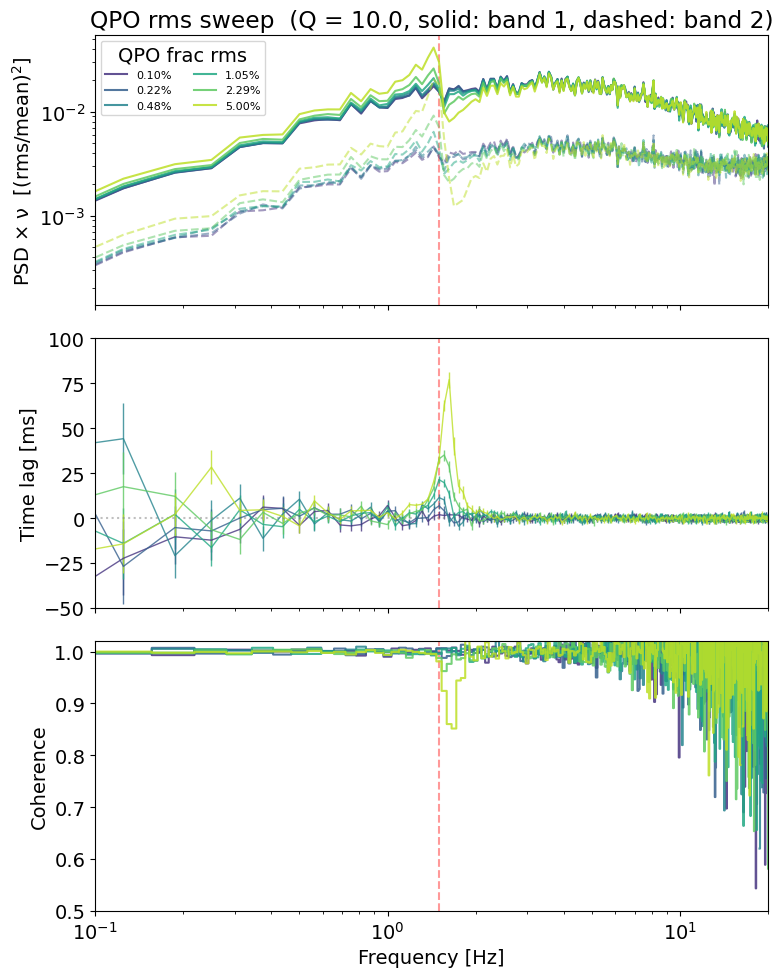

In [82]:
import numpy as np
import matplotlib.pyplot as plt
from stingray import (simulator, Lightcurve, AveragedPowerspectrum,
                      AveragedCrossspectrum)

# --- Setup ---
dt   = 1/512
mean = 100
T    = 1024 / dt
rms  = 0.5

sim = simulator.Simulator(N=int(T), mean=mean, dt=dt, rms=rms, poisson=True)
w   = np.fft.rfftfreq(sim.N, d=sim.dt)[1:]

def lorentzian(f, f0, q, norm):
    df = f0 / q
    return norm * (df / np.pi) / ((f - f0)**2 + df**2)

psd_model = lorentzian(w, 0.4, 0.3, 1.0) + lorentzian(w, 2.0, 0.5, 1.2)
lc_bb     = sim.simulate(psd_model)
broadband = lc_bb.counts - lc_bb.counts.mean()

# --- DHO filter ---
def dho_filter(x, dt, f0, zeta, gain=1.0):
    N    = len(x)
    freq = np.fft.rfftfreq(N, d=dt)
    w_   = 2*np.pi*freq
    w0   = 2*np.pi*f0
    H    = w0**2 / (w0**2 - w_**2 + 2j*zeta*w0*w_)
    X    = np.fft.rfft(x - x.mean())
    return np.fft.irfft(gain * H * X, n=N)

# --- Fixed broadband levels ---
mean1, mean2     = 100., 40.
frac_bb_1, frac_bb_2 = 0.25, 0.12

broadband1 = broadband * (frac_bb_1 * mean1 / broadband.std())
broadband2 = broadband * (frac_bb_2 * mean2 / broadband.std())

# --- DHO QPO response ---
f0_qpo, zeta = 1.5, 0.05      # Q = 10
test_resp  = dho_filter(broadband, dt, f0=f0_qpo, zeta=zeta, gain=1.0)
qpo_unit   = test_resp / test_resp.std()

# --- Sweep over QPO fractional rms ---
frac_qpo_vals = np.geomspace(1e-3, 5e-2, 6)
seg = 16.0

t   = np.arange(lc_bb.n) * dt
rng = np.random.default_rng(11)

results = []
for frac_qpo in frac_qpo_vals:
    qpo_1 = qpo_unit * (frac_qpo * mean1)
    qpo_2 = qpo_unit * (frac_qpo * mean2)

    lc1 = Lightcurve(t, rng.poisson(np.clip(mean1 + broadband1 + qpo_1, 0, None)),
                     dt=dt, skip_checks=True)
    lc2 = Lightcurve(t, rng.poisson(np.clip(mean2 + broadband2 + qpo_2, 0, None)),
                     dt=dt, skip_checks=True)

    ps1 = AveragedPowerspectrum(lc1, segment_size=seg, norm='frac')
    ps2 = AveragedPowerspectrum(lc2, segment_size=seg, norm='frac')
    cs  = AveragedCrossspectrum(lc2, lc1, segment_size=seg, norm='frac')
    coh, _     = cs.intrinsic_coherence()
    lag, lag_e = cs.time_lag()

    results.append(dict(frac_qpo=frac_qpo, ps1=ps1, ps2=ps2, cs=cs,
                        coh=coh, lag=lag, lag_e=lag_e))

# --- Plot ---
# creating a dictionary
font = {'size': 14}
# using rc function
plt.rc('font', **font)
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)
cmap = plt.cm.viridis(np.linspace(0.15, 0.9, len(frac_qpo_vals)))

for ax in axes:
    ax.axvline(f0_qpo, ls='--', color='red', alpha=0.4)

for r, c in zip(results, cmap):
    lbl = f'{r["frac_qpo"]*100:.2f}%'
    axes[0].loglog(r['ps1'].freq, r['ps1'].freq*r['ps1'].power,
                   color=c, alpha=0.85, label=lbl)
    axes[0].loglog(r['ps2'].freq, r['ps2'].freq*r['ps2'].power,
                   color=c, alpha=0.5, ls='--')
    axes[1].errorbar(r['cs'].freq, r['lag']*1e3, yerr=r['lag_e']*1e3,
                     color=c, alpha=0.8, ms=3, lw = 1)
    axes[2].semilogx(r['cs'].freq, r['coh'], color=c, alpha=0.85,
                     drawstyle='steps-mid')


axes[0].set(ylabel=r'PSD × ν  [(rms/mean)$^2$]',
            title=rf'QPO rms sweep  (Q = {1/(2*zeta):.1f}, solid: band 1, dashed: band 2)')
axes[0].legend(title='QPO frac rms', fontsize=8, ncol=2)

axes[1].axhline(0.0, ls=':', color='gray', alpha=0.5)
axes[1].set(ylabel='Time lag [ms]')
axes[1].set_ylim(-50,100)

axes[2].set(xscale='log', xlabel='Frequency [Hz]', ylabel='Coherence',
            ylim=(0.5, 1.02), xlim=(0.1, 20))

plt.tight_layout()
plt.savefig("figures/hidden_qpo.pdf")
plt.show()

/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/simulator/simulator.py:390: UserWarning: Some bins of the light curve have counts < 0. Setting to 0
  warnings.warn("Some bins of the light curve have counts < 0. Setting to 0")
64it [00:00, 11431.05it/s]
64it [00:00, 12846.26it/s]
64it [00:00, 5533.84it/s]
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:1800: RuntimeWarning: divide by zero encountered in divide
  dphi = np.sqrt((1 - gsq) / (2 * gsq * n_ave))
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:1409: UserWarning: NaN values detected in intrinsic_coherence calculation. This happens when the powers are too close to the noise level, and the coherence is not well defined. Consider rebinning the spectra to increase the signal-to-noise ratio.
  warnings.warn(
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:1415: UserWarning: Zero values detected in intrinsic_coherence calculation. This u

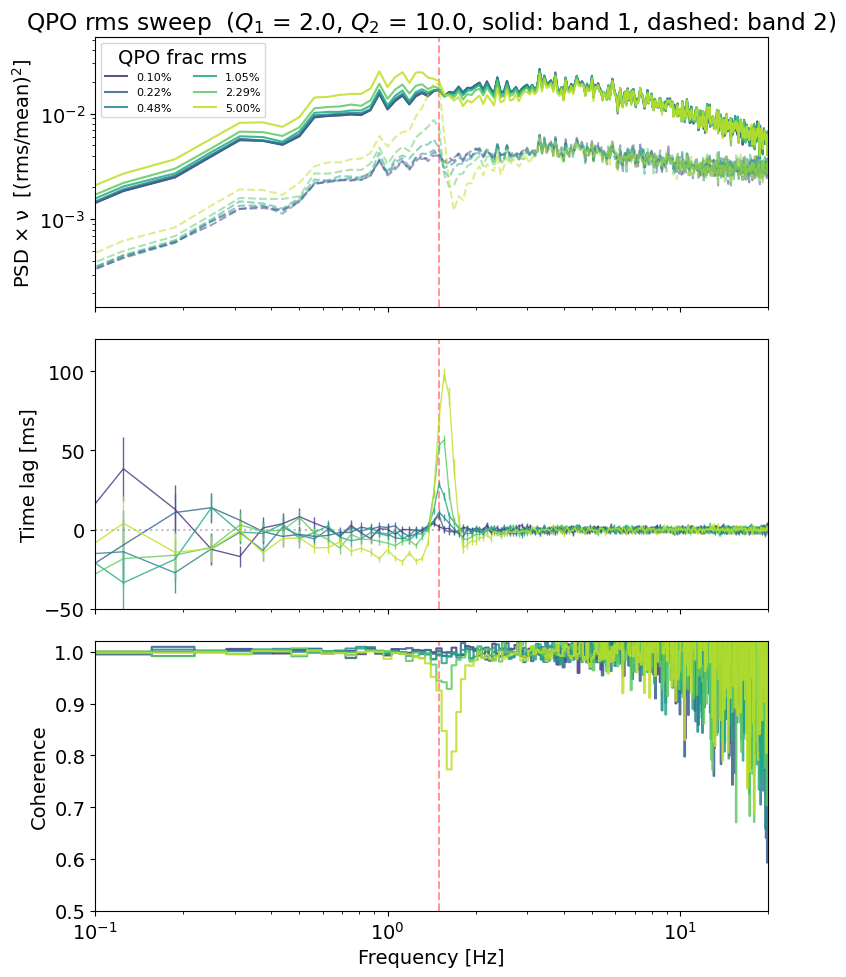

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from stingray import (simulator, Lightcurve, AveragedPowerspectrum,
                      AveragedCrossspectrum)

# --- Setup ---
dt   = 1/512
mean = 100
T    = 1024 / dt
rms  = 0.5

sim = simulator.Simulator(N=int(T), mean=mean, dt=dt, rms=rms, poisson=True)
w   = np.fft.rfftfreq(sim.N, d=sim.dt)[1:]

def lorentzian(f, f0, q, norm):
    df = f0 / q
    return norm * (df / np.pi) / ((f - f0)**2 + df**2)

psd_model = lorentzian(w, 0.4, 0.3, 1.0) + lorentzian(w, 2.0, 0.5, 1.2)
lc_bb     = sim.simulate(psd_model)
broadband = lc_bb.counts - lc_bb.counts.mean()

# --- DHO filter ---
def dho_filter(x, dt, f0, zeta, gain=1.0):
    N    = len(x)
    freq = np.fft.rfftfreq(N, d=dt)
    w_   = 2*np.pi*freq
    w0   = 2*np.pi*f0
    H    = w0**2 / (w0**2 - w_**2 + 2j*zeta*w0*w_)
    X    = np.fft.rfft(x - x.mean())
    return np.fft.irfft(gain * H * X, n=N)

# --- Fixed broadband levels ---
mean1, mean2     = 100., 40.
frac_bb_1, frac_bb_2 = 0.25, 0.12

broadband1 = broadband * (frac_bb_1 * mean1 / broadband.std())
broadband2 = broadband * (frac_bb_2 * mean2 / broadband.std())

# --- DHO QPO response ---
f0_qpo, zeta1, zeta2 = 1.5, 0.25, 0.05      # Q = 10
test_resp_1  = dho_filter(broadband, dt, f0=f0_qpo, zeta=zeta1, gain=1.0)
test_resp_2  = dho_filter(broadband, dt, f0=f0_qpo, zeta=zeta2, gain=1.0)
qpo_unit_1   = test_resp_1 / test_resp_1.std()
qpo_unit_2   = test_resp_2 / test_resp_2.std()

# --- Sweep over QPO fractional rms ---
frac_qpo_vals = np.geomspace(1e-3, 5e-2, 6)
seg = 16.0

t   = np.arange(lc_bb.n) * dt
rng = np.random.default_rng(11)

results = []
for frac_qpo in frac_qpo_vals:
    qpo_1 = qpo_unit_1 * (frac_qpo * mean1)
    qpo_2 = qpo_unit_2 * (frac_qpo * mean2)

    lc1 = Lightcurve(t, rng.poisson(np.clip(mean1 + broadband1 + qpo_1, 0, None)),
                     dt=dt, skip_checks=True)
    lc2 = Lightcurve(t, rng.poisson(np.clip(mean2 + broadband2 + qpo_2, 0, None)),
                     dt=dt, skip_checks=True)

    ps1 = AveragedPowerspectrum(lc1, segment_size=seg, norm='frac')
    ps2 = AveragedPowerspectrum(lc2, segment_size=seg, norm='frac')
    cs  = AveragedCrossspectrum(lc2, lc1, segment_size=seg, norm='frac')
    coh, _     = cs.intrinsic_coherence()
    lag, lag_e = cs.time_lag()

    results.append(dict(frac_qpo=frac_qpo, ps1=ps1, ps2=ps2, cs=cs,
                        coh=coh, lag=lag, lag_e=lag_e))

# --- Plot ---
# creating a dictionary
font = {'size': 14}
# using rc function
plt.rc('font', **font)
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)
cmap = plt.cm.viridis(np.linspace(0.15, 0.9, len(frac_qpo_vals)))

for ax in axes:
    ax.axvline(f0_qpo, ls='--', color='red', alpha=0.4)

for r, c in zip(results, cmap):
    lbl = f'{r["frac_qpo"]*100:.2f}%'
    axes[0].loglog(r['ps1'].freq, r['ps1'].freq*r['ps1'].power,
                   color=c, alpha=0.85, label=lbl)
    axes[0].loglog(r['ps2'].freq, r['ps2'].freq*r['ps2'].power,
                   color=c, alpha=0.5, ls='--')
    axes[1].errorbar(r['cs'].freq, r['lag']*1e3, yerr=r['lag_e']*1e3,
                     color=c, alpha=0.8, ms=3, lw = 1)
    axes[2].semilogx(r['cs'].freq, r['coh'], color=c, alpha=0.85,
                     drawstyle='steps-mid')


axes[0].set(ylabel=r'PSD × ν  [(rms/mean)$^2$]',
            title=rf'QPO rms sweep  ($Q_1$ = {1/(2*zeta1):.1f}, $Q_2$ = {1/(2*zeta2):.1f}, solid: band 1, dashed: band 2)')
axes[0].legend(title='QPO frac rms', fontsize=8, ncol=2)

axes[1].axhline(0.0, ls=':', color='gray', alpha=0.5)
axes[1].set(ylabel='Time lag [ms]')
axes[1].set_ylim(-50,120)

axes[2].set(xscale='log', xlabel='Frequency [Hz]', ylabel='Coherence',
            ylim=(0.5, 1.02), xlim=(0.1, 20))

plt.tight_layout()
plt.savefig("figures/hidden_qpo_damped.pdf")
plt.show()

/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/simulator/simulator.py:390: UserWarning: Some bins of the light curve have counts < 0. Setting to 0
  warnings.warn("Some bins of the light curve have counts < 0. Setting to 0")
64it [00:00, 8772.97it/s]
64it [00:00, 6485.67it/s]
64it [00:00, 6079.11it/s]
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:1800: RuntimeWarning: divide by zero encountered in divide
  dphi = np.sqrt((1 - gsq) / (2 * gsq * n_ave))
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:1409: UserWarning: NaN values detected in intrinsic_coherence calculation. This happens when the powers are too close to the noise level, and the coherence is not well defined. Consider rebinning the spectra to increase the signal-to-noise ratio.
  warnings.warn(
64it [00:00, 10975.81it/s]
64it [00:00, 14097.02it/s]
64it [00:00, 6117.35it/s]
64it [00:00, 12856.72it/s]
64it [00:00, 13513.67it/s]
64it [00:00, 5398.51it/s]

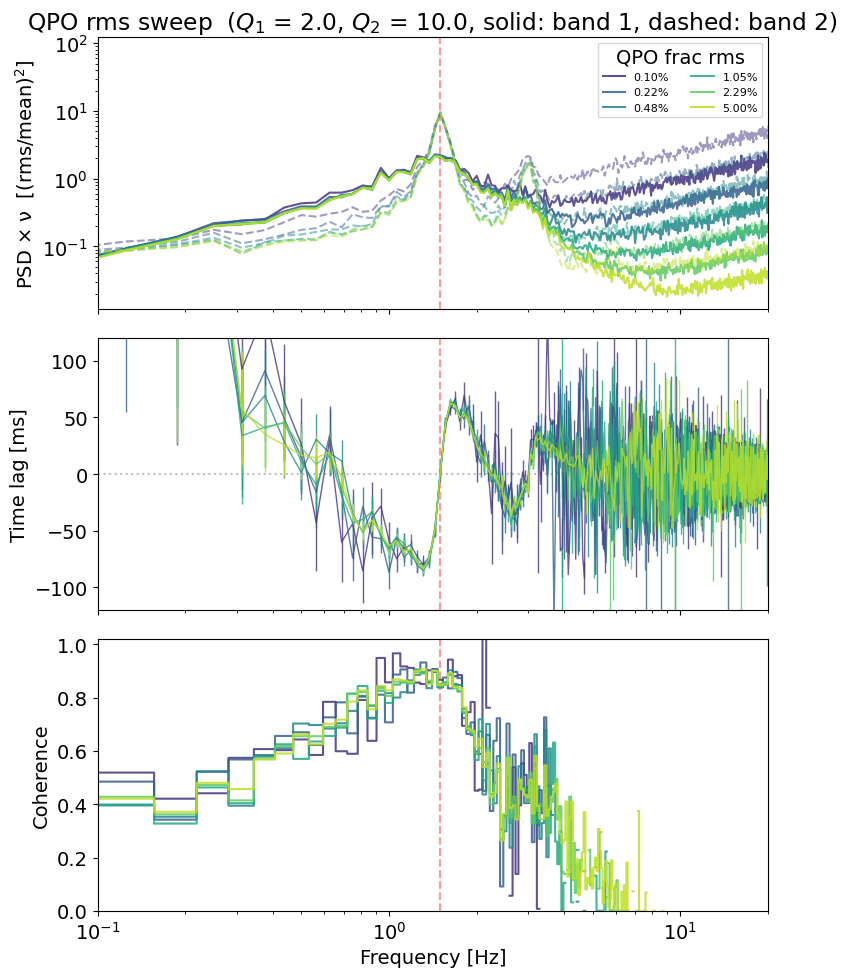

In [83]:
import numpy as np
import matplotlib.pyplot as plt
from stingray import (simulator, Lightcurve, AveragedPowerspectrum,
                      AveragedCrossspectrum)

# --- Setup ---
dt   = 1/512
mean = 100
T    = 1024 / dt
rms  = 0.5

sim = simulator.Simulator(N=int(T), mean=mean, dt=dt, rms=rms, poisson=True)
w   = np.fft.rfftfreq(sim.N, d=sim.dt)[1:]

def lorentzian(f, f0, q, norm):
    df = f0 / q
    return norm * (df / np.pi) / ((f - f0)**2 + df**2)

psd_model = lorentzian(w, 0.4, 0.3, 1.0) + lorentzian(w, 2.0, 0.5, 1.2)
lc_bb     = sim.simulate(psd_model)
broadband = lc_bb.counts - lc_bb.counts.mean()

# --- DHO filter ---
def dho_filter(x, dt, f0, zeta, gain=1.0):
    N    = len(x)
    freq = np.fft.rfftfreq(N, d=dt)
    w_   = 2*np.pi*freq
    w0   = 2*np.pi*f0
    H    = w0**2 / (w0**2 - w_**2 + 2j*zeta*w0*w_)
    X    = np.fft.rfft(x - x.mean())
    return np.fft.irfft(gain * H * X, n=N)

# --- Fixed broadband levels ---
mean1, mean2     = 100., 40.
frac_bb_1, frac_bb_2 = 0.25, 0.12

broadband1 = broadband * (frac_bb_1 * mean1 / broadband.std())
broadband2 = broadband * (frac_bb_2 * mean2 / broadband.std())

# --- DHO QPO response ---
f0_qpo, zeta1, zeta2 = 1.5, 0.25, 0.05      # Q = 10
test_resp_1  = dho_filter(broadband, dt, f0=f0_qpo, zeta=zeta1, gain=1.0)
test_resp_2  = dho_filter(broadband, dt, f0=f0_qpo, zeta=zeta2, gain=1.0)
qpo_unit_1   = test_resp_1 / test_resp_1.std()
qpo_unit_2   = test_resp_2 / test_resp_2.std()

# --- Sweep over QPO fractional rms ---
frac_qpo_vals = np.geomspace(1e-3, 5e-2, 6)
seg = 16.0

t   = np.arange(lc_bb.n) * dt
rng = np.random.default_rng(11)

results = []
for frac_qpo in frac_qpo_vals:
    qpo_1 = qpo_unit_1 * (frac_qpo * mean1)
    qpo_2 = qpo_unit_2 * (frac_qpo * mean2)

    lc1 = Lightcurve(t, rng.poisson(np.clip(qpo_1, 0, None)),
                     dt=dt, skip_checks=True)
    lc2 = Lightcurve(t, rng.poisson(np.clip(qpo_2, 0, None)),
                     dt=dt, skip_checks=True)

    ps1 = AveragedPowerspectrum(lc1, segment_size=seg, norm='frac')
    ps2 = AveragedPowerspectrum(lc2, segment_size=seg, norm='frac')
    cs  = AveragedCrossspectrum(lc2, lc1, segment_size=seg, norm='frac')
    coh, _     = cs.intrinsic_coherence()
    lag, lag_e = cs.time_lag()

    results.append(dict(frac_qpo=frac_qpo, ps1=ps1, ps2=ps2, cs=cs,
                        coh=coh, lag=lag, lag_e=lag_e))

# --- Plot ---
# creating a dictionary
font = {'size': 14}
# using rc function
plt.rc('font', **font)
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)
cmap = plt.cm.viridis(np.linspace(0.15, 0.9, len(frac_qpo_vals)))

for ax in axes:
    ax.axvline(f0_qpo, ls='--', color='red', alpha=0.4)

for r, c in zip(results, cmap):
    lbl = f'{r["frac_qpo"]*100:.2f}%'
    axes[0].loglog(r['ps1'].freq, r['ps1'].freq*r['ps1'].power,
                   color=c, alpha=0.85, label=lbl)
    axes[0].loglog(r['ps2'].freq, r['ps2'].freq*r['ps2'].power,
                   color=c, alpha=0.5, ls='--')
    axes[1].errorbar(r['cs'].freq, r['lag']*1e3, yerr=r['lag_e']*1e3,
                     color=c, alpha=0.8, ms=3, lw = 1)
    axes[2].semilogx(r['cs'].freq, r['coh'], color=c, alpha=0.85,
                     drawstyle='steps-mid')


axes[0].set(ylabel=r'PSD × ν  [(rms/mean)$^2$]',
            title=rf'QPO rms sweep  ($Q_1$ = {1/(2*zeta1):.1f}, $Q_2$ = {1/(2*zeta2):.1f}, solid: band 1, dashed: band 2)')
axes[0].legend(title='QPO frac rms', fontsize=8, ncol=2)

axes[1].axhline(0.0, ls=':', color='gray', alpha=0.5)
axes[1].set(ylabel='Time lag [ms]')
axes[1].set_ylim(-120,120)

axes[2].set(xscale='log', xlabel='Frequency [Hz]', ylabel='Coherence',
            ylim=(0.0, 1.02), xlim=(0.1, 20))

plt.tight_layout()
plt.savefig("figures/qpo_damped.pdf")
plt.show()

/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/simulator/simulator.py:390: UserWarning: Some bins of the light curve have counts < 0. Setting to 0
  warnings.warn("Some bins of the light curve have counts < 0. Setting to 0")
64it [00:00, 11548.09it/s]
64it [00:00, 13933.84it/s]
64it [00:00, 6896.58it/s]
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:1800: RuntimeWarning: divide by zero encountered in divide
  dphi = np.sqrt((1 - gsq) / (2 * gsq * n_ave))
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:939: RuntimeWarning: invalid value encountered in divide
  uncertainty = (2**0.5 * coherence * (1 - coherence)) / (np.sqrt(coherence) * n_ave**0.5)
64it [00:00, 14925.52it/s]
64it [00:00, 14216.47it/s]
64it [00:00, 7031.71it/s]
64it [00:00, 15079.80it/s]
64it [00:00, 13805.57it/s]
64it [00:00, 7238.97it/s]
64it [00:00, 12999.93it/s]
64it [00:00, 12922.32it/s]
64it [00:00, 6948.17it/s]
64it [00:00, 13211.71it/s]
64it [

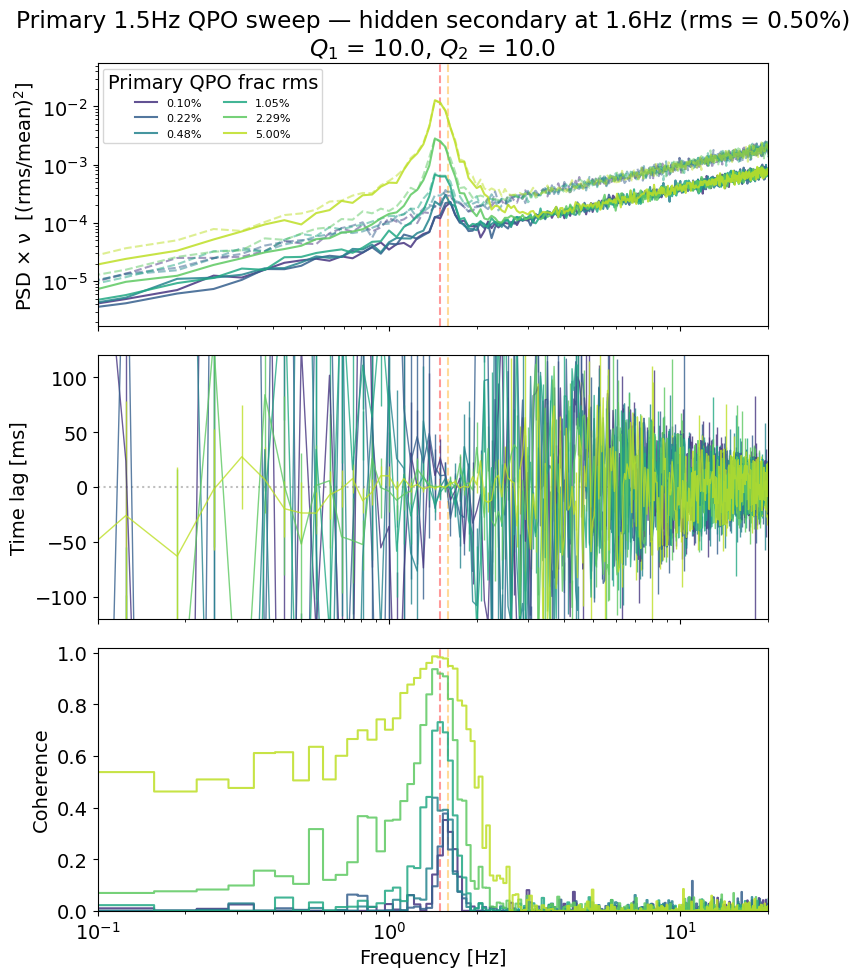

In [97]:
import numpy as np
import matplotlib.pyplot as plt
from stingray import (simulator, Lightcurve, AveragedPowerspectrum,
                      AveragedCrossspectrum)

# --- Setup ---
dt   = 1/512
mean = 100
T    = 1024 / dt
rms  = 0.5

# Two independent broadband realizations (one per QPO driver)
sim_a = simulator.Simulator(N=int(T), mean=mean, dt=dt, rms=rms, poisson=True, random_state=1)
sim_b = simulator.Simulator(N=int(T), mean=mean, dt=dt, rms=rms, poisson=True, random_state=2)
w     = np.fft.rfftfreq(sim_a.N, d=sim_a.dt)[1:]

def lorentzian(f, f0, q, norm):
    df = f0 / q
    return norm * (df / np.pi) / ((f - f0)**2 + df**2)

psd_model = lorentzian(w, 0.4, 0.3, 1.0) + lorentzian(w, 2.0, 0.5, 1.2)
lc_a      = sim_a.simulate(psd_model)
lc_b      = sim_b.simulate(psd_model)

broadband_a = lc_a.counts - lc_a.counts.mean()   # drives primary QPO
broadband_b = lc_b.counts - lc_b.counts.mean()   # drives secondary QPO (independent!)

# Observable broadband (use realization A so band 1/2 broadband is the shared one)
broadband = broadband_a

# --- DHO filter ---
def dho_filter(x, dt, f0, zeta, gain=1.0):
    N    = len(x)
    freq = np.fft.rfftfreq(N, d=dt)
    w_   = 2*np.pi*freq
    w0   = 2*np.pi*f0
    H    = w0**2 / (w0**2 - w_**2 + 2j*zeta*w0*w_)
    X    = np.fft.rfft(x - x.mean())
    return np.fft.irfft(gain * H * X, n=N)

# --- Fixed broadband levels ---
mean1, mean2         = 100., 40.
frac_bb_1, frac_bb_2 = 0.25, 0.12

broadband1 = broadband * (frac_bb_1 * mean1 / broadband.std())
broadband2 = broadband * (frac_bb_2 * mean2 / broadband.std())

# --- Two QPOs ---
# Primary: f0 = 1.5 Hz, narrow (Q=10) — driven by broadband A
# Secondary (hidden): f0 = 2.0 Hz, broader (Q=5) — driven by INDEPENDENT broadband B
f0_pri, zeta_pri = 1.5, 0.05    # Q = 10
f0_sec, zeta_sec = 1.6, 0.05    # Q = 10

resp_pri_1 = dho_filter(broadband_a, dt, f0=f0_pri, zeta=zeta_pri, gain=1.0)
resp_pri_2 = dho_filter(broadband_a, dt, f0=f0_pri, zeta=zeta_pri, gain=1.0)
resp_sec_1 = dho_filter(broadband_b, dt, f0=f0_sec, zeta=zeta_sec, gain=1.0)
resp_sec_2 = dho_filter(broadband_b, dt, f0=f0_sec, zeta=zeta_sec, gain=1.0)

qpo_pri_unit_1 = resp_pri_1 / resp_pri_1.std()
qpo_pri_unit_2 = resp_pri_2 / resp_pri_2.std()
qpo_sec_unit_1 = resp_sec_1 / resp_sec_1.std()
qpo_sec_unit_2 = resp_sec_2 / resp_sec_2.std()

# Secondary QPO fixed at small fractional rms (the "hidden" one)
frac_qpo_sec = 5e-3

# --- Sweep over PRIMARY QPO fractional rms ---
frac_qpo_vals = np.geomspace(1e-3, 5e-2, 6)
seg = 16.0
t   = np.arange(lc_a.n) * dt
rng = np.random.default_rng(11)

results = []
for frac_qpo in frac_qpo_vals:
    qpo_pri_1 = qpo_pri_unit_1 * (frac_qpo     * mean1)
    qpo_pri_2 = qpo_pri_unit_2 * (frac_qpo     * mean2)
    qpo_sec_1 = qpo_sec_unit_1 * (frac_qpo_sec * mean1)
    qpo_sec_2 = qpo_sec_unit_2 * (frac_qpo_sec * mean2)

    rate1 = mean1 + qpo_pri_1 + qpo_sec_1
    rate2 = mean2 + qpo_pri_2 + qpo_sec_2

    lc1 = Lightcurve(t, rng.poisson(np.clip(rate1, 0, None)), dt=dt, skip_checks=True)
    lc2 = Lightcurve(t, rng.poisson(np.clip(rate2, 0, None)), dt=dt, skip_checks=True)

    ps1 = AveragedPowerspectrum(lc1, segment_size=seg, norm='frac')
    ps2 = AveragedPowerspectrum(lc2, segment_size=seg, norm='frac')
    cs  = AveragedCrossspectrum(lc2, lc1, segment_size=seg, norm='frac')
    coh, _     = cs.coherence()
    lag, lag_e = cs.time_lag()

    results.append(dict(frac_qpo=frac_qpo, ps1=ps1, ps2=ps2, cs=cs,
                        coh=coh, lag=lag, lag_e=lag_e))

# --- Plot ---
font = {'size': 14}
plt.rc('font', **font)

fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)
cmap = plt.cm.viridis(np.linspace(0.15, 0.9, len(frac_qpo_vals)))

for ax in axes:
    ax.axvline(f0_pri, ls='--', color='red',    alpha=0.4)
    ax.axvline(f0_sec, ls='--', color='orange', alpha=0.4)

for r, c in zip(results, cmap):
    lbl = f'{r["frac_qpo"]*100:.2f}%'
    axes[0].loglog(r['ps1'].freq, r['ps1'].freq*r['ps1'].power,
                   color=c, alpha=0.85, label=lbl)
    axes[0].loglog(r['ps2'].freq, r['ps2'].freq*r['ps2'].power,
                   color=c, alpha=0.5, ls='--')
    axes[1].errorbar(r['cs'].freq, r['lag']*1e3, yerr=r['lag_e']*1e3,
                     color=c, alpha=0.8, ms=3, lw=1)
    axes[2].semilogx(r['cs'].freq, r['coh'], color=c, alpha=0.85,
                     drawstyle='steps-mid')

axes[0].set(ylabel=r'PSD × ν  [(rms/mean)$^2$]',
            title=(rf'Primary {f0_pri}Hz QPO sweep — hidden secondary at {f0_sec}Hz '
                   rf'(rms = {frac_qpo_sec*100:.2f}%)'
                   '\n'
                   rf'$Q_1$ = {1/(2*zeta_pri):.1f}, $Q_2$ = {1/(2*zeta_sec):.1f}'))
axes[0].legend(title='Primary QPO frac rms', fontsize=8, ncol=2)

axes[1].axhline(0.0, ls=':', color='gray', alpha=0.5)
axes[1].set(ylabel='Time lag [ms]', ylim=(-120, 120))

axes[2].set(xscale='log', xlabel='Frequency [Hz]', ylabel='Coherence',
            ylim=(0.0, 1.02), xlim=(0.1, 20))

plt.tight_layout()
plt.savefig("figures/two_incoherent_qpos.pdf")
plt.show()

/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/simulator/simulator.py:390: UserWarning: Some bins of the light curve have counts < 0. Setting to 0
  warnings.warn("Some bins of the light curve have counts < 0. Setting to 0")
64it [00:00, 12239.44it/s]
64it [00:00, 13637.24it/s]
64it [00:00, 5283.95it/s]
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:1800: RuntimeWarning: divide by zero encountered in divide
  dphi = np.sqrt((1 - gsq) / (2 * gsq * n_ave))
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:939: RuntimeWarning: invalid value encountered in divide
  uncertainty = (2**0.5 * coherence * (1 - coherence)) / (np.sqrt(coherence) * n_ave**0.5)
64it [00:00, 12010.00it/s]
64it [00:00, 13125.79it/s]
64it [00:00, 5536.92it/s]
64it [00:00, 13674.76it/s]
64it [00:00, 12144.20it/s]
64it [00:00, 6398.18it/s]
64it [00:00, 13829.04it/s]
64it [00:00, 14143.81it/s]
64it [00:00, 6352.90it/s]
64it [00:00, 12808.26it/s]
64it [

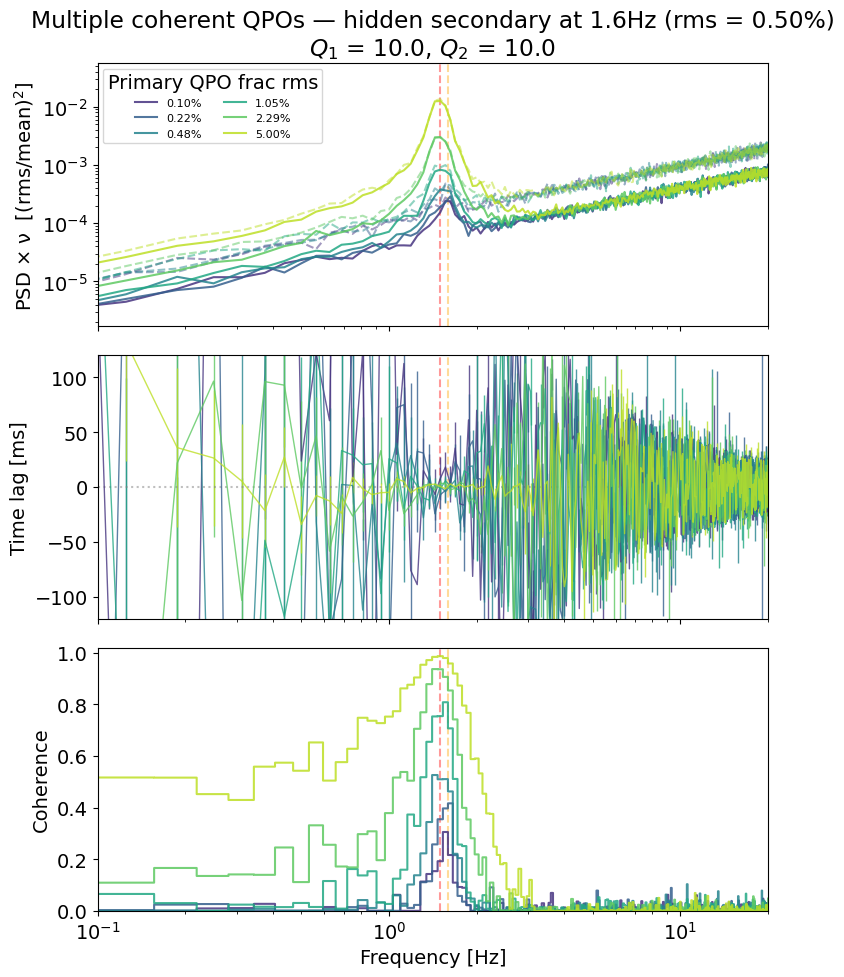

In [96]:
import numpy as np
import matplotlib.pyplot as plt
from stingray import (simulator, Lightcurve, AveragedPowerspectrum,
                      AveragedCrossspectrum)

# --- Setup ---
dt   = 1/512
mean = 100
T    = 1024 / dt
rms  = 0.5

# Two independent broadband realizations (one per QPO driver)
sim_a = simulator.Simulator(N=int(T), mean=mean, dt=dt, rms=rms, poisson=True, random_state=1)
w     = np.fft.rfftfreq(sim_a.N, d=sim_a.dt)[1:]

def lorentzian(f, f0, q, norm):
    df = f0 / q
    return norm * (df / np.pi) / ((f - f0)**2 + df**2)

psd_model = lorentzian(w, 0.4, 0.3, 1.0) + lorentzian(w, 2.0, 0.5, 1.2)
lc_a      = sim_a.simulate(psd_model)

broadband = lc_a.counts - lc_a.counts.mean()   # drives primary QPO

# Observable broadband (use realization A so band 1/2 broadband is the shared one)
broadband = broadband

# --- DHO filter ---
def dho_filter(x, dt, f0, zeta, gain=1.0):
    N    = len(x)
    freq = np.fft.rfftfreq(N, d=dt)
    w_   = 2*np.pi*freq
    w0   = 2*np.pi*f0
    H    = w0**2 / (w0**2 - w_**2 + 2j*zeta*w0*w_)
    X    = np.fft.rfft(x - x.mean())
    return np.fft.irfft(gain * H * X, n=N)

# --- Fixed broadband levels ---
mean1, mean2         = 100., 40.
frac_bb_1, frac_bb_2 = 0.25, 0.12

broadband1 = broadband * (frac_bb_1 * mean1 / broadband.std())
broadband2 = broadband * (frac_bb_2 * mean2 / broadband.std())

# --- Two QPOs ---
# Primary: f0 = 1.5 Hz, narrow (Q=10) — driven by broadband A
# Secondary (hidden): f0 = 2.0 Hz, broader (Q=5) — driven by INDEPENDENT broadband B
f0_pri, zeta_pri = 1.5, 0.05    # Q = 10
f0_sec, zeta_sec = 1.6, 0.05    # Q = 10

resp_pri = dho_filter(broadband, dt, f0=f0_pri, zeta=zeta_pri, gain=1.0)
resp_sec = dho_filter(broadband, dt, f0=f0_sec, zeta=zeta_sec, gain=1.0)

qpo_pri_unit = resp_pri / resp_pri.std()
qpo_sec_unit = resp_sec / resp_sec.std()

# Secondary QPO fixed at small fractional rms (the "hidden" one)
frac_qpo_sec = 5e-3

# --- Sweep over PRIMARY QPO fractional rms ---
frac_qpo_vals = np.geomspace(1e-3, 5e-2, 6)
seg = 16.0
t   = np.arange(lc_a.n) * dt
rng = np.random.default_rng(11)

results = []
for frac_qpo in frac_qpo_vals:
    qpo_pri_1 = qpo_pri_unit * (frac_qpo     * mean1)
    qpo_pri_2 = qpo_pri_unit * (frac_qpo     * mean2)
    qpo_sec_1 = qpo_sec_unit * (frac_qpo_sec * mean1)
    qpo_sec_2 = qpo_sec_unit * (frac_qpo_sec * mean2)

    rate1 = mean1 + qpo_pri_1 + qpo_sec_1
    rate2 = mean2 + qpo_pri_2 + qpo_sec_2

    lc1 = Lightcurve(t, rng.poisson(np.clip(rate1, 0, None)), dt=dt, skip_checks=True)
    lc2 = Lightcurve(t, rng.poisson(np.clip(rate2, 0, None)), dt=dt, skip_checks=True)

    ps1 = AveragedPowerspectrum(lc1, segment_size=seg, norm='frac')
    ps2 = AveragedPowerspectrum(lc2, segment_size=seg, norm='frac')
    cs  = AveragedCrossspectrum(lc2, lc1, segment_size=seg, norm='frac')
    coh, _     = cs.coherence()
    lag, lag_e = cs.time_lag()

    results.append(dict(frac_qpo=frac_qpo, ps1=ps1, ps2=ps2, cs=cs,
                        coh=coh, lag=lag, lag_e=lag_e))

# --- Plot ---
font = {'size': 14}
plt.rc('font', **font)

fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)
cmap = plt.cm.viridis(np.linspace(0.15, 0.9, len(frac_qpo_vals)))

for ax in axes:
    ax.axvline(f0_pri, ls='--', color='red',    alpha=0.4)
    ax.axvline(f0_sec, ls='--', color='orange', alpha=0.4)

for r, c in zip(results, cmap):
    lbl = f'{r["frac_qpo"]*100:.2f}%'
    axes[0].loglog(r['ps1'].freq, r['ps1'].freq*r['ps1'].power,
                   color=c, alpha=0.85, label=lbl)
    axes[0].loglog(r['ps2'].freq, r['ps2'].freq*r['ps2'].power,
                   color=c, alpha=0.5, ls='--')
    axes[1].errorbar(r['cs'].freq, r['lag']*1e3, yerr=r['lag_e']*1e3,
                     color=c, alpha=0.8, ms=3, lw=1)
    axes[2].semilogx(r['cs'].freq, r['coh'], color=c, alpha=0.85,
                     drawstyle='steps-mid')

axes[0].set(ylabel=r'PSD × ν  [(rms/mean)$^2$]',
            title=(rf'Multiple coherent QPOs — hidden secondary at {f0_sec}Hz (rms = {frac_qpo_sec*100:.2f}%)'
                   '\n'
                   rf'$Q_1$ = {1/(2*zeta_pri):.1f}, $Q_2$ = {1/(2*zeta_sec):.1f}'))
axes[0].legend(title='Primary QPO frac rms', fontsize=8, ncol=2)

axes[1].axhline(0.0, ls=':', color='gray', alpha=0.5)
axes[1].set(ylabel='Time lag [ms]', ylim=(-120, 120))

axes[2].set(xscale='log', xlabel='Frequency [Hz]', ylabel='Coherence',
            ylim=(0.0, 1.02), xlim=(0.1, 20))

plt.tight_layout()
plt.savefig("figures/two_coherent_qpos.pdf")
plt.show()

/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/simulator/simulator.py:390: UserWarning: Some bins of the light curve have counts < 0. Setting to 0
  warnings.warn("Some bins of the light curve have counts < 0. Setting to 0")
64it [00:00, 10936.46it/s]
64it [00:00, 12312.99it/s]
64it [00:00, 6293.77it/s]
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:1800: RuntimeWarning: divide by zero encountered in divide
  dphi = np.sqrt((1 - gsq) / (2 * gsq * n_ave))
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:939: RuntimeWarning: invalid value encountered in divide
  uncertainty = (2**0.5 * coherence * (1 - coherence)) / (np.sqrt(coherence) * n_ave**0.5)
64it [00:00, 12973.54it/s]
64it [00:00, 12000.33it/s]
64it [00:00, 6619.05it/s]
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:1800: RuntimeWarning: divide by zero encountered in divide
  dphi = np.sqrt((1 - gsq) / (2 * gsq * n_ave))
/opt/minico

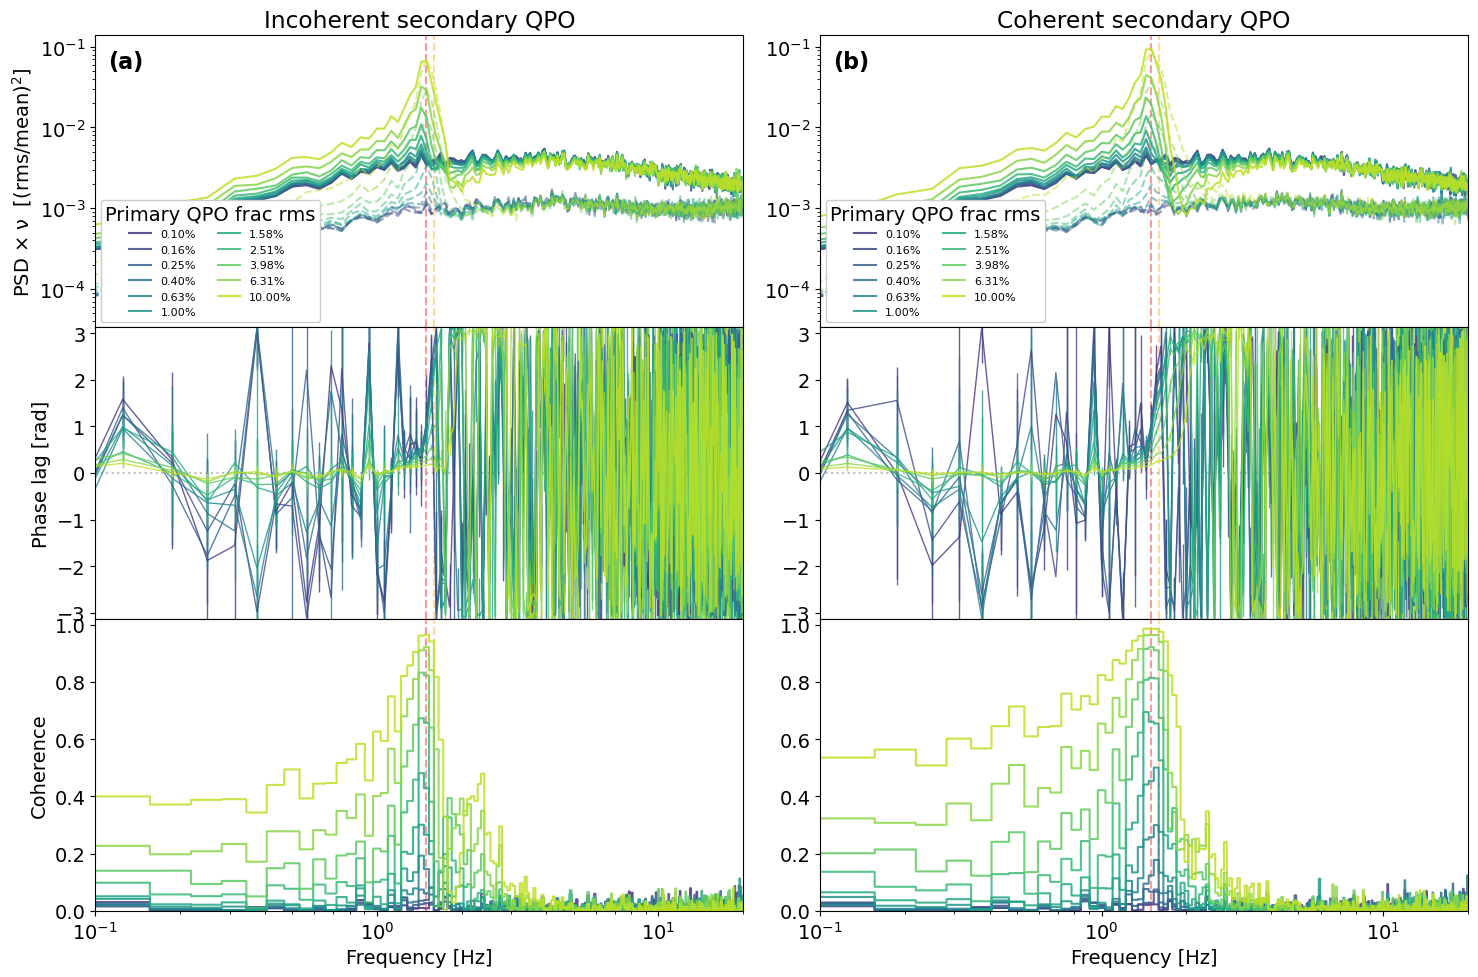

In [154]:
import numpy as np
import matplotlib.pyplot as plt
from stingray import (simulator, Lightcurve, AveragedPowerspectrum,
                      AveragedCrossspectrum)

# --- Setup ---
dt   = 1/512
mean = 100
T    = 1024 / dt
rms  = 0.5

# Two independent broadband realizations (one per QPO driver, for incoherent case)
sim_a = simulator.Simulator(N=int(T), mean=mean, dt=dt, rms=rms, poisson=True, random_state=5)
sim_b = simulator.Simulator(N=int(T), mean=mean, dt=dt, rms=rms, poisson=True, random_state=6)
w     = np.fft.rfftfreq(sim_a.N, d=sim_a.dt)[1:]

def lorentzian(f, f0, q, norm):
    df = f0 / q
    return norm * (df / np.pi) / ((f - f0)**2 + df**2)

psd_1_model = lorentzian(w, 0.4, 0.3, 1.0) + lorentzian(w, 2.0, 0.5, 1.2)
psd_2_model = lorentzian(w, 0.4, 0.3, 1.0) + lorentzian(w, 2.0, 0.5, 1.2)
lc_a      = sim_a.simulate(psd_1_model)
lc_b      = sim_b.simulate(psd_2_model)

broadband_a = lc_a.counts - lc_a.counts.mean()
broadband_b = lc_b.counts - lc_b.counts.mean()

# --- DHO filter ---
def dho_filter(x, dt, f0, zeta, gain=1.0):
    N    = len(x)
    freq = np.fft.rfftfreq(N, d=dt)
    w_   = 2*np.pi*freq
    w0   = 2*np.pi*f0
    H    = w0**2 / (w0**2 - w_**2 + 2j*zeta*w0*w_)
    X    = np.fft.rfft(x - x.mean())
    return np.fft.irfft(gain * H * X, n=N)

# --- Fixed broadband levels ---
mean1, mean2         = 100., 100.
frac_bb_1, frac_bb_2 = 0.12, 0.06

broadband_a = broadband_a * (frac_bb_1 * mean1 / broadband_a.std())
broadband_b = broadband_b * (frac_bb_2 * mean2 / broadband_b.std())

# --- QPO parameters (preserved from both scripts) ---
f0_pri, zeta_pri = 1.5, 0.05    # Q = 10
f0_sec, zeta_sec = 1.6, 0.05    # Q = 10
frac_qpo_vals_pri     = np.geomspace(1e-3, 1e-1, 11)
frac_qpo_vals_sec     = frac_qpo_vals_pri * 0.5
seg              = 16.0

# Unit-rms QPO responses
# Coherent case: both QPOs driven by broadband_a (shared driver)
qpo_pri_unit_coh = (dho_filter(broadband_a, dt, f0=f0_pri, zeta=zeta_pri, gain=1.0) /
                    dho_filter(broadband_a, dt, f0=f0_pri, zeta=zeta_pri, gain=1.0).std())
qpo_sec_unit_coh = (dho_filter(broadband_a, dt, f0=f0_sec, zeta=zeta_sec, gain=1.0) /
                    dho_filter(broadband_a, dt, f0=f0_sec, zeta=zeta_sec, gain=1.0).std())

# Incoherent case: primary from broadband_a, secondary from broadband_b
qpo_pri_unit_inc = (dho_filter(broadband_a, dt, f0=f0_pri, zeta=zeta_pri, gain=1.0) /
                    dho_filter(broadband_a, dt, f0=f0_pri, zeta=zeta_pri, gain=1.0).std())
qpo_sec_unit_inc = (dho_filter(broadband_b, dt, f0=f0_sec, zeta=zeta_sec, gain=1.0) /
                    dho_filter(broadband_b, dt, f0=f0_sec, zeta=zeta_sec, gain=1.0).std())

# --- Sweep helper ---
def run_sweep(qpo_pri_unit, qpo_sec_unit, broadband_pri, broadband_sec, seed=11):
    t   = np.arange(lc_a.n) * dt
    rng = np.random.default_rng(seed)
    out = []
    for frac_qpo, frac_qpo_sec in zip(frac_qpo_vals_pri, frac_qpo_vals_sec):
        qpo_pri_1 = qpo_pri_unit * (frac_qpo     * mean1)
        qpo_pri_2 = qpo_pri_unit * (frac_qpo     * mean2)
        qpo_sec_1 = qpo_sec_unit * (frac_qpo_sec * mean1)
        qpo_sec_2 = qpo_sec_unit * (frac_qpo_sec * mean2)

        rate1 = mean1 + broadband_pri + qpo_pri_1 + qpo_sec_1
        rate2 = mean2 + broadband_sec + qpo_pri_2 + qpo_sec_2

        lc1 = Lightcurve(t, rng.poisson(np.clip(rate1, 0, None)), dt=dt, skip_checks=True)
        lc2 = Lightcurve(t, rng.poisson(np.clip(rate2, 0, None)), dt=dt, skip_checks=True)

        ps1 = AveragedPowerspectrum(lc1, segment_size=seg, norm='frac')
        ps2 = AveragedPowerspectrum(lc2, segment_size=seg, norm='frac')
        cs  = AveragedCrossspectrum(lc2, lc1, segment_size=seg, norm='frac')

        ps1.rebin_log(f=0.05)
        ps2.rebin_log(f=0.05)
        cs.rebin_log(f=0.05)
        coh, _     = cs.coherence()
        lag, lag_e = cs.time_lag()
        phase_lag, phase_lag_e = cs.phase_lag()

        out.append(dict(frac_qpo=frac_qpo, ps1=ps1, ps2=ps2, cs=cs,
                        coh=coh, lag=lag, lag_e=lag_e, phase_lag=phase_lag, phase_lag_e=phase_lag_e))
    return out

results_inc = run_sweep(qpo_pri_unit_inc, qpo_sec_unit_inc, broadband_a, broadband_b)
results_coh = run_sweep(qpo_pri_unit_coh, qpo_sec_unit_coh, broadband_a, broadband_b)

# --- Plot ---
font = {'size': 14}
plt.rc('font', **font)

fig, axes = plt.subplots(3, 2, figsize=(15, 10), sharex=True,
                         gridspec_kw={'hspace':0})
# Share y-axis within each row for direct comparison
for row in range(3):
    axes[row, 1].sharey(axes[row, 0])

cmap = plt.cm.viridis(np.linspace(0.15, 0.9, len(frac_qpo_vals)))

phase = True # Set to True for phase lag, False for time lag

for col, results in enumerate([results_inc, results_coh]):
    ax_ps, ax_lag, ax_coh = axes[0, col], axes[1, col], axes[2, col]

    for ax in (ax_ps, ax_lag, ax_coh):
        ax.axvline(f0_pri, ls='--', color='red',    alpha=0.4)
        ax.axvline(f0_sec, ls='--', color='orange', alpha=0.4)

    for r, c in zip(results, cmap):
        lbl = f'{r["frac_qpo"]*100:.2f}%'
        ax_ps.loglog(r['ps1'].freq, r['ps1'].freq*r['ps1'].power,
                     color=c, alpha=0.85, label=lbl)
        ax_ps.loglog(r['ps2'].freq, r['ps2'].freq*r['ps2'].power,
                     color=c, alpha=0.5, ls='--')
        if phase == True:
            ax_lag.errorbar(r['cs'].freq, r['phase_lag'], yerr=r['phase_lag_e'],
                            color=c, alpha=0.8, ms=3, lw=1)
        else:
            ax_lag.errorbar(r['cs'].freq, r['lag']*1e3, yerr=r['lag_e']*1e3,
                            color=c, alpha=0.8, ms=3, lw=1)
        ax_coh.semilogx(r['cs'].freq, r['coh'], color=c, alpha=0.85,
                        drawstyle='steps-mid')

    ax_lag.axhline(0.0, ls=':', color='gray', alpha=0.5)
    if phase == True:
        ax_lag.set_ylim((r['phase_lag'])[(r['ps2'].freq>0.1)&(r['ps2'].freq<20)].min(), (r['phase_lag'])[(r['ps2'].freq>0.1)&(r['ps2'].freq<20)].max())
    else:
        ax_lag.set_ylim((r['lag']*1e3)[(r['ps2'].freq>0.1)&(r['ps2'].freq<20)].min(), (r['lag']*1e3)[(r['ps2'].freq>0.1)&(r['ps2'].freq<20)].max())
    ax_coh.set(xscale='log', ylim=(0.0, 1.02), xlim=(0.1, 20))

# Column titles
axes[0, 0].set_title('Incoherent secondary QPO')
axes[0, 1].set_title('Coherent secondary QPO')

# Y labels only on left column
axes[0, 0].set_ylabel(r'PSD × ν  [(rms/mean)$^2$]')
if phase == True:
    axes[1, 0].set_ylabel('Phase lag [rad]')
else:
    axes[1, 0].set_ylabel('Time lag [ms]')
axes[2, 0].set_ylabel('Coherence')

# X labels only on bottom row
axes[2, 0].set_xlabel('Frequency [Hz]')
axes[2, 1].set_xlabel('Frequency [Hz]')

# Single legend on top-left
axes[0, 0].legend(title='Primary QPO frac rms', fontsize=8, ncol=2, loc='lower left', framealpha=1.0)
axes[0, 1].legend(title='Primary QPO frac rms', fontsize=8, ncol=2, loc='lower left', framealpha=1.0)

# Panel labels
axes[0, 0].text(0.02, 0.95, '(a)', transform=axes[0, 0].transAxes,
                ha='left', va='top', fontsize=16, fontweight='bold')
axes[0, 1].text(0.02, 0.95, '(b)', transform=axes[0, 1].transAxes,
                ha='left', va='top', fontsize=16, fontweight='bold')

plt.tight_layout()
fig.subplots_adjust(hspace=0)   # tight_layout resets hspace; reapply after
plt.savefig("figures/two_qpos_comparison.pdf")
plt.show()